In [34]:
# ===========================
# Phase III modeling: Base vs Cluster, Regressor + Classifier
# ===========================

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score, average_precision_score, classification_report
from lightgbm import LGBMRegressor, LGBMClassifier

# ---------------------------
# 0. Load data (already engineered)
# ---------------------------
df = pd.read_csv("/Users/KrisLiu/Downloads/patient_features_with_encounter_cluster.csv")

# Ensure types
df['encounter_start_dt'] = pd.to_datetime(df['encounter_start_dt'], errors='coerce')
df['encounter_end_dt']   = pd.to_datetime(df['encounter_end_dt'],   errors='coerce')


In [35]:
# ---------------------------
# 1. Targets
# ---------------------------
# A) Duration regression target (unchanged)
target_days = 'encounter_duration_days'

# B) Count target (choose one)
#    Option 1 (your original): past_num_encounters (historical)
target_count = 'past_num_encounters'
#    Option 2 (optional): current encounter procedure count
# target_count = 'proc_count'  # uncomment to switch

# C) Short vs Long classifier target
#    Define long-stay threshold in days (e.g., >= 3 days is long)
long_stay_threshold = 3.0
df['is_long_stay'] = (df[target_days] >= long_stay_threshold).astype(int)


In [36]:
# ---------------------------
# 2. Feature sets
#    Remove encounter_setting; keep encounter_medical_service (categorical).
#    Cluster version adds 'encounter_cluster'.
# ---------------------------
base_features = [
    'age', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
    'encounter_medical_service',
    'past_num_encounters', 'past_total_procedures',
    'past_total_icd_codes', 'past_total_encounter_days'
    # DO NOT include encounter_setting
]

cluster_features = base_features + ['encounter_cluster']

# Sanity: keep only columns that exist
base_features    = [c for c in base_features    if c in df.columns]
cluster_features = [c for c in cluster_features if c in df.columns]


In [37]:
# ---------------------------
# 3. Train/Test split with GroupKFold (by patient)
#    We first create a single holdout split to report metrics consistently.
# ---------------------------
# Create groups
groups = df['patient_id'].astype(str)

# Single split (80/20) preserving groups
# To use GroupKFold for a single split, we can manually take the first fold as test
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(df, groups=groups))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

def build_preproc(feature_list):
    # separate categorical and numeric
    cat_cols = [c for c in feature_list if df[c].dtype == 'object']
    num_cols = [c for c in feature_list if c not in cat_cols]

    preproc = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
            ('num', 'passthrough', num_cols)
        ],
        remainder='drop'
    )
    return preproc, cat_cols, num_cols

def fit_and_eval_reg(feature_list, y_col, label):
    preproc, cat_cols, num_cols = build_preproc(feature_list)
    model = LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    pipe = Pipeline([
        ('prep', preproc),
        ('lgbm', model)
    ])
    X_tr, y_tr = df_train[feature_list], df_train[y_col]
    X_te, y_te = df_test[feature_list],  df_test[y_col]

    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)

    mae = mean_absolute_error(y_te, pred)
    r2  = r2_score(y_te, pred)
    print(f"[{label}] Regression {y_col}: MAE={mae:.3f}, R²={r2:.3f}")
    return pipe, pred, {'MAE': mae, 'R2': r2}

def fit_and_eval_cls(feature_list, y_col, label):
    preproc, cat_cols, num_cols = build_preproc(feature_list)
    clf = LGBMClassifier(
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42
    )
    pipe = Pipeline([
        ('prep', preproc),
        ('lgbm', clf)
    ])
    X_tr, y_tr = df_train[feature_list], df_train[y_col]
    X_te, y_te = df_test[feature_list],  df_test[y_col]

    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:,1]
    pred  = (proba >= 0.5).astype(int)

    auc = roc_auc_score(y_te, proba)
    ap  = average_precision_score(y_te, proba)
    print(f"[{label}] Classifier {y_col}: AUC={auc:.3f}, PR-AUC={ap:.3f}")
    print(classification_report(y_te, pred, digits=3))
    return pipe, proba, {'AUC': auc, 'PR_AUC': ap}
    

In [58]:
# ---------------------------
# 4. Train & evaluate (Base vs Cluster)
# ---------------------------
print("Data shape:", df.shape)

# Regressors
base_reg_count, base_pred_count, base_count_m = fit_and_eval_reg(base_features, target_count,  "Base")
base_reg_days,  base_pred_days,  base_days_m  = fit_and_eval_reg(base_features, target_days,   "Base")

cluster_reg_count, cluster_pred_count, cluster_count_m = fit_and_eval_reg(cluster_features, target_count, "Cluster")
cluster_reg_days,  cluster_pred_days,  cluster_days_m  = fit_and_eval_reg(cluster_features, target_days,  "Cluster")

# Classifier (short vs long)
base_cls,    base_prob_long,    base_cls_m    = fit_and_eval_cls(base_features,   'is_long_stay', "Base")
cluster_cls, cluster_prob_long, cluster_cls_m = fit_and_eval_cls(cluster_features,'is_long_stay', "Cluster")

# ===== After training classifiers =====
# cluster_cls is the trained Pipeline model
# cluster_prob_long is its predicted probability on df_test

df_test = df_test.copy()
df_test["score_long_stay_cluster"] = cluster_prob_long  # model output score

# (optional) also save base model score if you want to compare later
df_test["score_long_stay_base"] = base_prob_long


Data shape: (15116, 27)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002987 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 315
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 30
[LightGBM] [Info] Start training from score 0.740655
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Base] Regression past_num_encounters: MAE=0.207, R²=0.634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can se

In [64]:
# ---------------------------
# 5. Service-level workload comparison (using predictions)
#    For days: use predicted duration; for count: use predicted count.
# ---------------------------
# --- Compute Ground Truth Workload and Average LOS ---
df_truth = (
    df_test.groupby("encounter_medical_service")
    .agg(
        Total_LOS_truth=("encounter_duration_days", "sum"),
        Avg_LOS_truth=("encounter_duration_days", "mean")
    )
)

print("Ground truth calculated:")
display(df_truth.head())

def agg_workload(df_sub, pred_count, pred_days):
    tmp = df_sub[['encounter_medical_service']].copy()
    tmp['pred_count'] = pred_count
    tmp['pred_days']  = pred_days
    grp = tmp.groupby('encounter_medical_service').agg(
        Patients=('pred_days','size'),
        Avg_pred_count=('pred_count','mean'),
        Avg_pred_days =('pred_days','mean')
    )
    grp['Total_workload_days'] = grp['Avg_pred_days'] * grp['Patients']
    return grp

base_work = agg_workload(df_test, base_pred_count,    base_pred_days)
clst_work = agg_workload(df_test, cluster_pred_count, cluster_pred_days)

comp = (base_work
        .join(clst_work, lsuffix="_base", rsuffix="_cluster")
        .join(df_truth)   # <--- 加这一行
        .assign(
            Delta_avg_days=lambda d: d['Avg_pred_days_cluster'] - d['Avg_pred_days_base'],
            Delta_total_days=lambda d: d['Total_workload_days_cluster'] - d['Total_workload_days_base']
        )
       ).sort_values('Total_workload_days_base', ascending=False)

print("\n=== Global metrics (test set) ===")
print("  Model    MAE_count   R2_count   MAE_days   R2_days   AUC(long)  PR-AUC(long)")
print(f"  Base     {base_count_m['MAE']:.3f}       {base_count_m['R2']:.3f}     {base_days_m['MAE']:.3f}    {base_days_m['R2']:.3f}     {base_cls_m['AUC']:.3f}      {base_cls_m['PR_AUC']:.3f}")
print(f"  Cluster  {cluster_count_m['MAE']:.3f}       {cluster_count_m['R2']:.3f}     {cluster_days_m['MAE']:.3f}    {cluster_days_m['R2']:.3f}     {cluster_cls_m['AUC']:.3f}      {cluster_cls_m['PR_AUC']:.3f}")

print("\n=== Workload comparison by medical service (Cluster vs Base) ===")
print(comp.reset_index().to_string(index=False))



Ground truth calculated:


,Total_LOS_truth,Avg_LOS_truth
encounter_medical_service,,
Cardiology,590.522917,10.736780
Cardiovascular services,72.579861,6.048322
Cath lab,99.235417,19.847083
Critical care medicine,388.378472,6.472975
Emergency medicine,344.151389,0.460095



=== Global metrics (test set) ===
  Model    MAE_count   R2_count   MAE_days   R2_days   AUC(long)  PR-AUC(long)
  Base     0.207       0.634     9.195    0.085     0.810      0.769
  Cluster  0.212       0.623     9.208    0.088     0.808      0.764

=== Workload comparison by medical service (Cluster vs Base) ===
           encounter_medical_service  Patients_base  Avg_pred_count_base  Avg_pred_days_base  Total_workload_days_base  Patients_cluster  Avg_pred_count_cluster  Avg_pred_days_cluster  Total_workload_days_cluster  Total_LOS_truth  Avg_LOS_truth  Delta_avg_days  Delta_total_days
        Nursing - medical / surgical           1574             0.522406           13.760912              21659.676089              1574                0.521603              13.798640                 21719.059286     21468.667361      13.639560        0.037728         59.383197
                     General surgery            184             0.413340            8.624613               1586.928747      

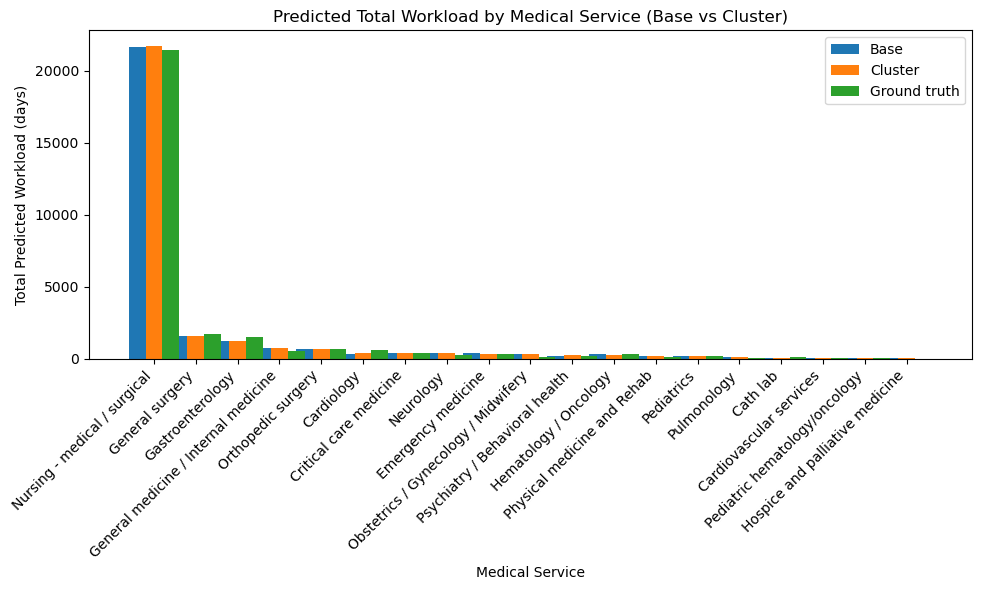

Caption (Figure 1):
Figure 1. Predicted Workload by Medical Service


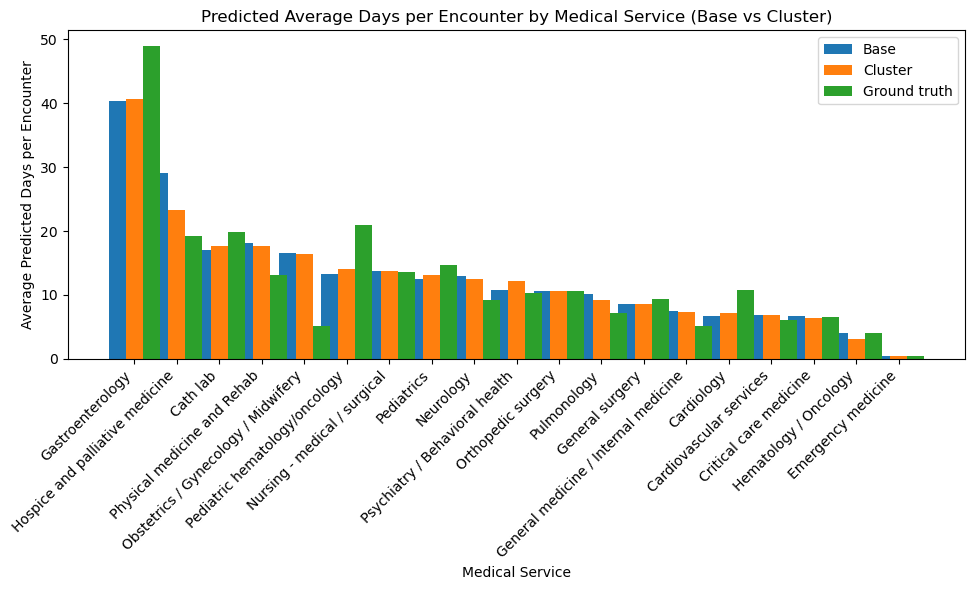

Caption (Figure 2):
Figure 2. Predicted Average Days per Encounter by Medical Service
Saved: workload_total_by_service.png and avg_pred_days_by_service.png


In [68]:
# ===== FINAL CELL: Generate and save Figure A & Figure B =====
# This cell assumes you already have a DataFrame named `comp`
# where medical service is the index and the listed columns exist.

import matplotlib.pyplot as plt

# --- 1) Make sure the service is a real column (from index) ---
def _ensure_service_column(df, fallback_name="encounter_medical_service"):
    """
    If service is the index, move it into a column.
    Return the new DataFrame and the service column name.
    """
    if df.index.name is None:
        # index has no name; use a sensible default
        df2 = df.reset_index().rename(columns={"index": fallback_name})
        return df2, fallback_name
    else:
        svc_col = df.index.name
        df2 = df.reset_index()
        return df2, svc_col

df_plot, svc_col = _ensure_service_column(comp)

# --- 2) Sanity checks for required columns ---
req_cols = [
    "Total_workload_days_base", "Total_workload_days_cluster",
    "Avg_pred_days_base", "Avg_pred_days_cluster",
]
missing = [c for c in req_cols if c not in df_plot.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}\nAvailable: {list(df_plot.columns)}")

# --- 3) Figure A: Total Predicted Workload (Base vs Cluster) ---
figA_path = "workload_total_by_service.png"   # change if needed

# Sort for readability (by cluster workload descending)
dfA = df_plot[[svc_col,
               "Total_workload_days_base",
               "Total_workload_days_cluster",
               "Total_LOS_truth"   # new
              ]].copy()
dfA = dfA.sort_values(by="Total_workload_days_cluster", ascending=False)

plt.figure(figsize=(10, 6))
x = range(len(dfA))
w = 0.4  # bar width

plt.bar([i - w for i in x], dfA["Total_workload_days_base"], width=w, label="Base")
plt.bar(x, dfA["Total_workload_days_cluster"], width=w, label="Cluster")
plt.bar([i + w for i in x], dfA["Total_LOS_truth"], width=w, label="Ground truth") #new

plt.xticks(list(x), dfA[svc_col].astype(str).tolist(), rotation=45, ha="right")
plt.xlabel("Medical Service")
plt.ylabel("Total Predicted Workload (days)")
plt.title("Predicted Total Workload by Medical Service (Base vs Cluster)")
plt.legend()
plt.tight_layout()
plt.savefig(figA_path, dpi=200, bbox_inches="tight")
plt.show()

print("Caption (Figure 1):")
print("Figure 1. Predicted Workload by Medical Service")

# --- 4) Figure B: Average Predicted Days per Encounter (Base vs Cluster) ---
figB_path = "avg_pred_days_by_service.png"    # change if needed

# Sort for readability (by cluster average duration descending)
dfB = df_plot[[svc_col,
               "Avg_pred_days_base",
               "Avg_pred_days_cluster",
               "Avg_LOS_truth"     # new
              ]].copy()
dfB = dfB.sort_values(by="Avg_pred_days_cluster", ascending=False)

plt.figure(figsize=(10, 6))
x = range(len(dfB))
w = 0.4  # bar width

plt.bar([i - w for i in x], dfB["Avg_pred_days_base"], width=w, label="Base")
plt.bar(x, dfB["Avg_pred_days_cluster"], width=w, label="Cluster")
plt.bar([i + w for i in x], dfB["Avg_LOS_truth"], width=w, label="Ground truth") #new

plt.xticks(list(x), dfB[svc_col].astype(str).tolist(), rotation=45, ha="right")
plt.xlabel("Medical Service")
plt.ylabel("Average Predicted Days per Encounter")
plt.title("Predicted Average Days per Encounter by Medical Service (Base vs Cluster)")
plt.legend()
plt.tight_layout()
plt.savefig(figB_path, dpi=200, bbox_inches="tight")
plt.show()

print("Caption (Figure 2):")
print("Figure 2. Predicted Average Days per Encounter by Medical Service")
print(f"Saved: {figA_path} and {figB_path}")


In [44]:
df_test.columns.tolist()


['patient_id',
 'encounter_id',
 'icd_prefix3_unique_str',
 'n_icd_prefix3',
 'encounter_start_dt',
 'encounter_end_dt',
 'encounter_duration_days',
 'encounter_setting',
 'encounter_medical_service',
 'adt_event_types_seq_str',
 'adt_event_times_seq_str',
 'PATIENT_BIRTH_YEAR',
 'PATIENT_SEX',
 'PATIENT_RACE_ETHNICITY',
 'DECEASED_FLAG',
 'age',
 'med_order_nunique',
 'proc_codes_seq_str',
 'proc_descs_seq_str',
 'proc_times_seq_str',
 'proc_count',
 'past_num_encounters',
 'past_total_procedures',
 'past_total_icd_codes',
 'past_total_encounter_days',
 'encounter_cluster',
 'is_long_stay']

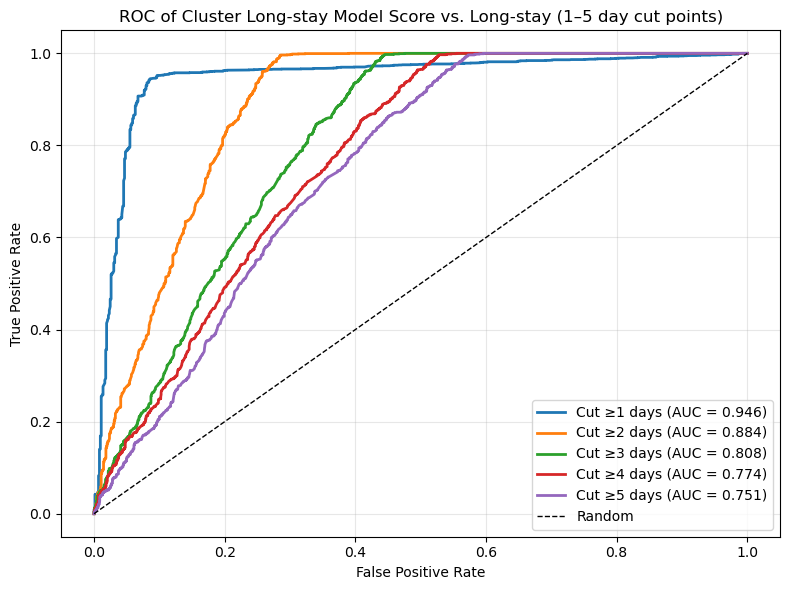

,cut_point_days,AUC
0,1,0.946303
1,2,0.884192
2,3,0.807645
3,4,0.774337
4,5,0.751261


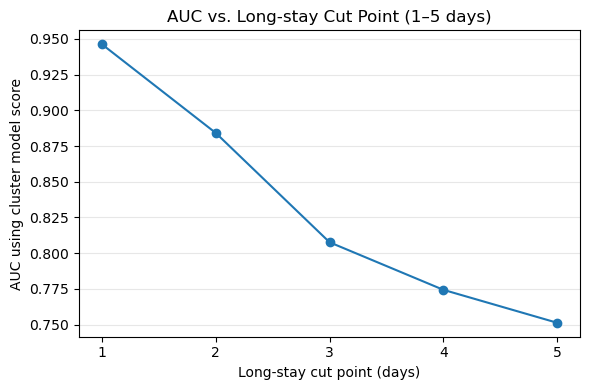

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Column configuration
LOS_COL    = "encounter_duration_days"      # true LOS
SCORE_COL  = "score_long_stay_cluster"      # <-- model probability score
CUT_POINTS = [1, 2, 3, 4, 5]

df_eval = df_test.copy()

auc_results = []
plt.figure(figsize=(8, 6))

for cp in CUT_POINTS:
    # define long-stay label under this cut point
    y_true = (df_eval[LOS_COL] >= cp).astype(int)

    # use FIXED model score
    y_score = df_eval[SCORE_COL]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)
    auc_results.append((cp, auc_val))

    plt.plot(fpr, tpr, lw=2, label=f"Cut ≥{cp} days (AUC = {auc_val:.3f})")

# random baseline
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC of Cluster Long-stay Model Score vs. Long-stay (1–5 day cut points)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# AUC table
auc_df = pd.DataFrame(auc_results, columns=["cut_point_days", "AUC"])
display(auc_df)

# AUC vs cut point plot
plt.figure(figsize=(6, 4))
plt.plot(auc_df["cut_point_days"], auc_df["AUC"], marker="o")
plt.xticks(auc_df["cut_point_days"])
plt.xlabel("Long-stay cut point (days)")
plt.ylabel("AUC using cluster model score")
plt.title("AUC vs. Long-stay Cut Point (1–5 days)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



Overall R² for encounter_duration_days (Cluster model, test set): 0.0882

R² by medical service (Cluster model, min_n=30):


/tmp/ipykernel_19434/464483570.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: safe_r2(g, min_n=30))


encounter_medical_service
Nursing - medical / surgical            -0.000844
Hematology / Oncology                   -0.045100
Orthopedic surgery                      -0.060817
General surgery                         -0.070995
Cardiology                              -0.101408
Critical care medicine                  -0.355006
Gastroenterology                        -0.413491
Neurology                               -0.597758
General medicine / Internal medicine    -1.204243
Emergency medicine                     -27.130931
dtype: float64

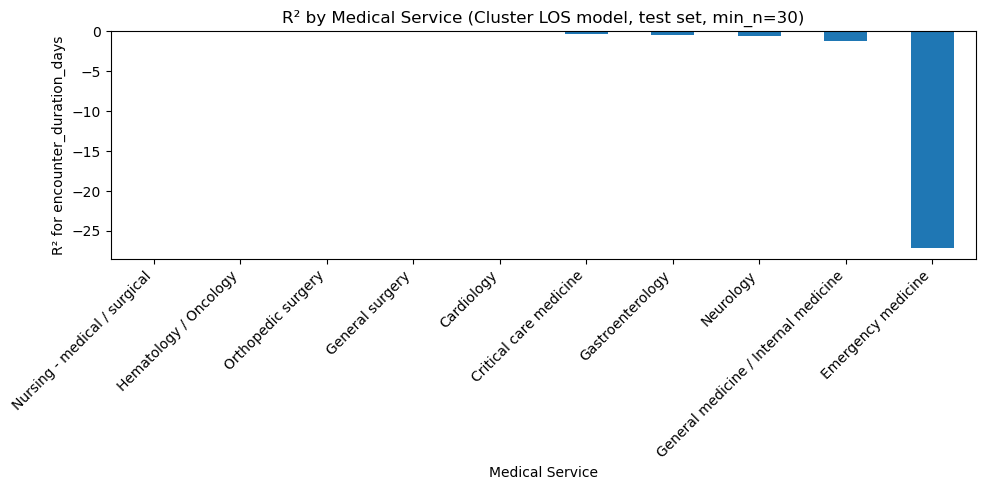

In [62]:
from sklearn.metrics import r2_score

y_true = df_test[target_days]
y_pred_cluster = cluster_pred_days

r2_overall = r2_score(y_true, y_pred_cluster)
print(f"Overall R² for encounter_duration_days (Cluster model, test set): {r2_overall:.4f}")

df_r2 = df_test.copy()
df_r2["pred_days_cluster"] = y_pred_cluster

def safe_r2(group, min_n=30):
    y_g = group[target_days]
    y_hat = group["pred_days_cluster"]

    # ignore very small services
    if len(group) < min_n:
        return np.nan
    if y_g.nunique() <= 1:
        return np.nan
    return r2_score(y_g, y_hat)

r2_by_service = (
    df_r2.groupby("encounter_medical_service")
         .apply(lambda g: safe_r2(g, min_n=30))
         .dropna()
         .sort_values(ascending=False)
)

print("\nR² by medical service (Cluster model, min_n=30):")
display(r2_by_service)

plt.figure(figsize=(10, 5))
r2_by_service.plot(kind="bar")
plt.ylabel("R² for encounter_duration_days")
plt.xlabel("Medical Service")
plt.title("R² by Medical Service (Cluster LOS model, test set, min_n=30)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
